# Migration M3 — Statistical Analysis

# Reproducibility

- **Generated at:** `2026-08-18T16:23:03.258209+00:00`
- **Code/commit reference:** `840a796`
- **Dataset row counts used:** customers=100,000, customer_profile=100,000, orders=100,000, raw_transactions=100,000, products=100,000
- **Metric contract:** all curated orders; Revenue=`SUM(sales)`, Profit=`SUM(profit)`, date axis=`order_date`, currency=INR.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from app.services.stats_service import run_statistical_analysis
result = await run_statistical_analysis()

In [2]:
pd.DataFrame(result['descriptive_statistics']).set_index('field')

,count,mean,median,mode,variance,std,q1,q3,min,max
field,,,,,,,,,,
sales,100000,25084.410142,25134.695000,1842.940000,2.074518e+08,14403.187686,12618.030000,37575.850000,100.570000,49999.890000
profit,100000,3755.305114,3317.450000,889.530000,6.968819e+06,2639.852035,1651.105000,5363.845000,6.520000,14563.670000
discount_pct,100000,25.131990,25.000000,31.000000,2.082950e+02,14.432430,13.000000,38.000000,0.000000,50.000000
quantity,100000,5.493760,5.000000,2.000000,8.271964e+00,2.876102,3.000000,8.000000,1.000000,10.000000
shipping_days,100000,3.991060,4.000000,1.000000,4.026260e+00,2.006554,2.000000,6.000000,1.000000,7.000000
profit_margin_pct,100000,14.965068,14.392639,9.090909,2.766176e+01,5.259445,10.794625,18.564973,5.000749,29.995818


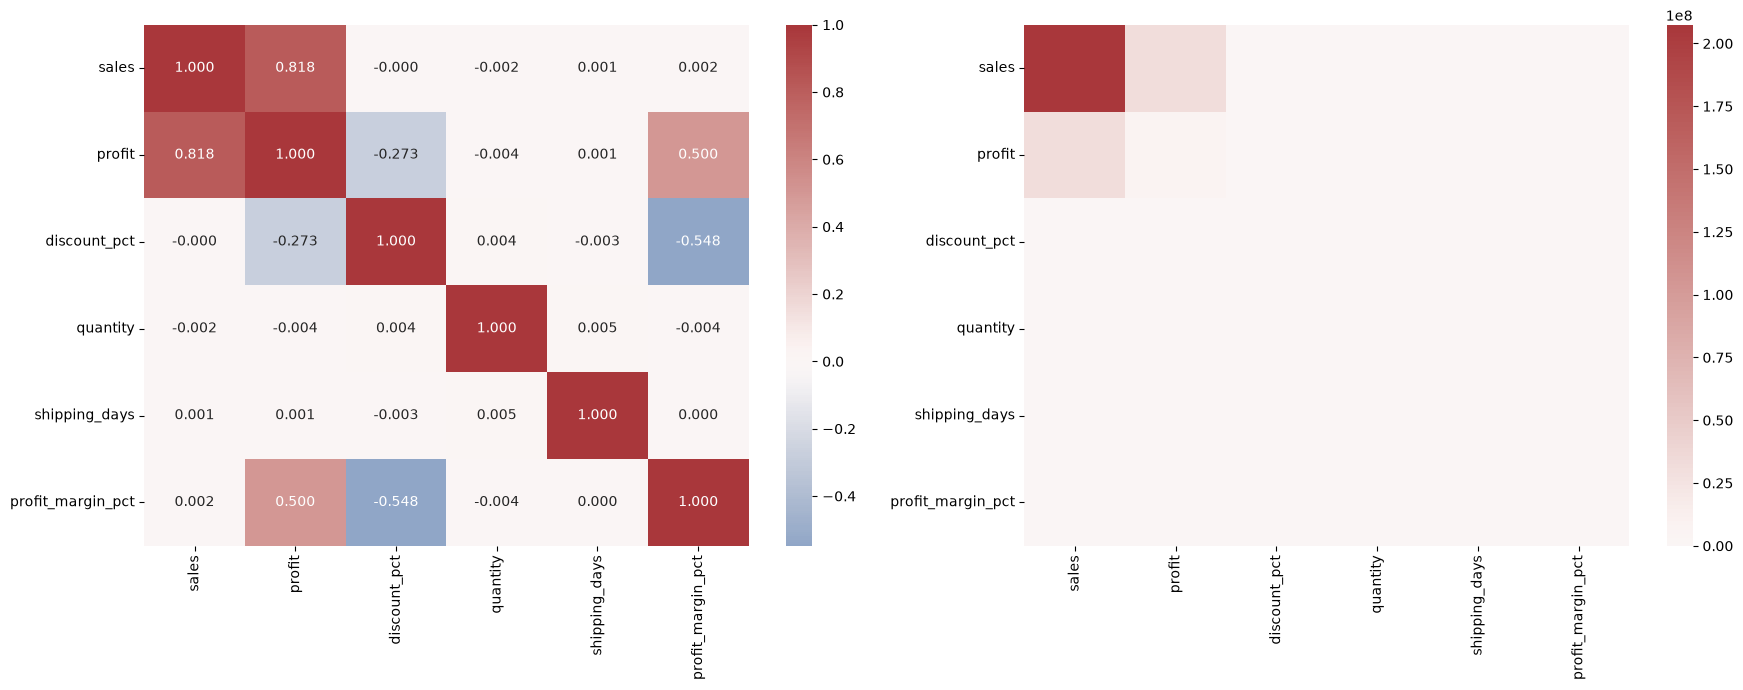

In [3]:
corr = pd.DataFrame(result['matrices']['correlation'])
cov = pd.DataFrame(result['matrices']['covariance'])
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.3f', ax=axes[0])
sns.heatmap(cov, cmap='vlag', center=0, ax=axes[1])
plt.tight_layout()

In [4]:
pd.DataFrame(result['hypothesis_tests'])

,name,null_hypothesis,statistic,p_value,dof,effect_size_name,effect_size,conclusion,groups,group_means,p_value_display,low_discount_cutoff_pct,high_discount_cutoff_pct,low_discount_n,high_discount_n,low_discount_mean_margin_pct,high_discount_mean_margin_pct
0,Chi-Square: category × customer segment,Product category and customer segment are inde...,6.410788,0.268273,5.0,Cramer's V,0.008007,No statistically significant category preferen...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,One-way ANOVA: profit margin across city types,Mean profit margin is equal across city types.,0.636929,0.528916,NaN,Eta-squared,0.000013,Profit margins do not differ significantly acr...,3.0,"{'Tier 1': 14.985230815898564, 'Tier 2': 14.94...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Welch t-test: profit margin for high- vs low-d...,Mean profit margin is equal for high- and low-...,-188.470729,0.000000,NaN,Cohen's d,-1.633368,High-discount orders have a materially lower m...,NaN,NaN,<1e-300,13.0,38.0,26706.0,25281.0,18.662281,11.249826
